`Предсказание показателя "Гармония Бессмертия"`

**Table of contents**<a id='toc0_'></a>    
- 1. [Предварительная обработка данных](#toc1_)    
  - 1.1. [Чтение и загрузка данных](#toc1_1_)    
  - 1.2. [Первичный анализ данных](#toc1_2_)    
  - 1.3. [Разделение выборки на обучающую и тестовую выборки](#toc1_3_)    
  - 1.4. [Обработка вещественных признаков (заполнение пропусков)](#toc1_4_)    
  - 1.5. [Кодирование категориальных признаков](#toc1_5_)    
  - 1.6. [Детекция выбросов и аномалий в данных](#toc1_6_)    
  - 1.7. [Подведение итогов раздела 1](#toc1_7_)    
- 2. [Генерация новых признаков](#toc2_)    
  - 2.1. [Корреляционный анализ входных признаков (построение тепловых карт корреляции)](#toc2_1_)    
  - 2.2. [Исправление проблемы мультиколлинеарности в данных](#toc2_2_)    
  - 2.3. [Скалирование данных](#toc2_3_)    
  - 2.4. [Подведение итогов раздела 2](#toc2_4_)    
- 3. [Выбор моделей ML и метрик](#toc3_)    
- 4. [Обучение моделей ML и подбор гиперпараметров](#toc4_)    
- 5. [Вычисление метрик на новых данных](#toc5_)    
- 6. [Результат работы](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

В рамках проекта решается задача задача машинного обучения с учителем — задача регрессии: прогнозирование непрерывной целевой переменной на основе обучающих данных с известными признаками и ответами.

Цель — построить модель, которая выявит взаимосвязи между признаками и целевым значением и сможет делать точные прогнозы на новых данных.

Работа выполнялась на версии `Python 3.13.8` в среде разработки VS Code.

На первом этапе необходимо настроить рабочее окружение для анализа данных и построения моделей. Во избежание конфликтов зависимостей мы зафиксируем версии ключевых библиотек и фреймворков, используемых в исследовании.

Используемые библиотеки и их версии:
```
pandas==2.3.3
scikit-learn==1.7.2
matplotlib==3.10.7
seaborn==0.13.2
pyod==2.0.5
scipy==1.16.2
optuna==4.5.0
joblib==1.5.2
numpy==2.3.3
shap==0.50.0
```

Пояснения к библиотекам:
- `pandas`: фреймворк для обработки и анализа структурированных данных (DataFrame/Series).
- `scikit-learn`: основной фреймворк для построения, обучения и оценки машинных моделей (классификация, регрессия, кластеризация).
- `matplotlib`, `seaborn` и `shap`: библиотеки для создания визуализаций.
- `pyod`: библиотека, специализирующаяся на алгоритмах обнаружения аномалий.
- `scipy`: набор инструментов для научных вычислений, включая статистические функции, оптимизацию и линейную алгебру.
- `optuna`: фреймворк для автоматизированного подбора гиперпараметров моделей машинного обучения.
- `joblib`: инструмент для эффективного сохранения и загрузки Python-объектов.
- `numpy`: фундаментальная библиотека для работы с многомерными массивами и выполнения численных операций.

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import logging
import optuna 
import shap

from scipy.linalg import LinAlgWarning
from scipy import stats

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, max_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.svm import SVR

from pyod.models.iforest import IForest
from pyod.models.ocsvm import OCSVM

В целях воспроизводимости на всех этапах работы, где задействована случайность (разбиение данных, обучение моделей), установлено фиксированное начальное значение (seed) для генератора псевдослучайных чисел. Для более информативного вывода часть логирования и предупреждений игнорируется, а то есть выключается.

In [27]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.ERROR)

# 1. <a id='toc1_'></a>[Предварительная обработка данных](#toc0_)

Исходный набор данных является структурированными наблюдениями за процессами, в контексте которых возникла потребность в решении задачи.

**Признаки:**
| Название | Тип | Мера |
|--------|-------|---------|
| Вектор мощи | числовой | ? |
| Скорость перехода через портал | числовой | ? |
| Приток Силы Потока | числовой | ? |
| Ритм магичекого ядра | числовой | RPM |
| Поток Энергий | числовой | RPM |
| Сила Левого Потока | числовой | ? |
| Сила Правого Потока | числовой | ? |
| Пламя Стихий | числовой | °С |
| Температура вдоха Истока | числовой | °С |
| Температура выдоха Истока | числовой | °С |
| Приток давления Выдоха Истока | числовой | ? |
| Давление вдоха Истока | числовой | ? |
| Давление выдоха Истока | числовой | ? |
| Древний Ветер | числовой | ? |
| Печать Чародея | числовой | % |
| Эмульсия Истока | числовой | ? |
| Дыхание Истока | числовой | ? |
| Тип Вектора Мощи | категориальный | метки |
| Номер пометки | числовой | уникальный номер |
| *Гармония Бессмертия (целевой)* | числовой | ? |

**Особые признаки (формулы):**
| Название | Формула |
|--------|-------|
| Сумма потоков | Сила Левого Потока + Сила Правого Потока|
| Общая сила потоков | Сумма потоков + Приток Силы Потока|
| Общая сила ядра | Ритм магичекого ядра * Приток Силы Потока|
| Общее давление | Приток давления Выдоха Истока + Давление выдоха Истока|
| Магическая производительность | Скорость перехода через портал / Эмульсия Истока|
| Эффективность ядра | Общая сила ядра / Эмульсия Истока|
| Магическая мощность | Эмульсия Истока * Общее давление * (Пламя Стихий - Температура вдоха Истока)|

Все формулы, используюцие целевой признак, отбрасываются. При использовании таковых формул будет явная утечка данных.

## 1.1. <a id='toc1_1_'></a>[Чтение и загрузка данных](#toc0_)

Данные разделены специфичным разделителем, а так же выбрана кодировка, отличная от UTF-8, так что чтение файла в датафрейм осуществляется с дополнительными параметрами. Так как индексаця строк не несёт полезной информации для предсказаний - столбец сразу удаляется.

In [28]:
df = pd.read_csv('portal_data.csv', sep='|', encoding='cp1251', na_values=['-', 'Не определено']).drop('Номер пометки', axis=1)
df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,645.642,2.078,NaN,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.71660,21624.934,201.516623,8470.013,175.239,175.239,681.658,736,628.950,2.087,NaN,10.990,1.027,23.803,0.471,1.00,1.000,Выше среднего
11930,6.175,9.25992,29763.213,241.561772,8800.352,245.954,245.954,747.405,736,NaN,2.512,NaN,13.109,NaN,32.671,0.647,1.00,1.000,Выше среднего
11931,7.148,10.80324,39003.867,280.444950,9120.889,332.389,332.389,796.457,736,680.393,2.982,NaN,15.420,1.036,42.104,0.834,1.00,1.000,Сильный
11932,8.206,12.34656,50992.579,323.315332,9300.274,438.024,438.024,892.945,736,NaN,3.594,NaN,18.293,NaN,58.064,1.149,1.00,1.000,Сильный


## 1.2. <a id='toc1_2_'></a>[Первичный анализ данных](#toc0_)

Первое, что следует сделать - осмотреть информацию о данных.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Температура выдоха Истока       2387 non-null   float64
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           2439 non-null   float64
 12  Давление выдоха Истока          

In [30]:
df.nunique()

Вектор Мощи                           9
Скорость перехода через портал        9
Приток Силы Потока                11430
Ритм магического ядра              3888
Поток Энергий                     11834
Сила Левого Потока                 4286
Сила Правого Потока                4286
Пламя Стихий                      11772
Температура вдоха Истока              1
Температура выдоха Истока          2368
Приток давления Выдоха Истока       524
Давление вдоха Истока                 1
Давление выдоха Истока             4209
Древний Ветер                        19
Печать Чародея                     8496
Эмульсия Истока                     696
Дыхание Истока                       51
Гармония Бессмертия                  26
Тип Вектора Мощи                      4
dtype: int64

Столбцы, в которых существует только одно уникальное значение ('Температура вдоха Истока', 'Давление вдоха Истока') - объективно бесполезны в решении задачи, они сохраняются в множество столбцов для удаления.

In [31]:
cols_to_drop = {'Температура вдоха Истока', 'Давление вдоха Истока'}

Столбцы, пропущенные значения в котором составляют 75% и более, тоже отправляются в множество столбцов для удаления.

In [32]:
cols_to_drop = cols_to_drop.union(set([col for col in df.columns if df[col].isna().mean() >= 0.75]))
cols_to_drop

{'Давление вдоха Истока',
 'Древний Ветер',
 'Температура вдоха Истока',
 'Температура выдоха Истока'}

Строки, в которых известно менее 50% информации так же не несут пользы, поэтому выясняется их наличие.

In [33]:
all_rows = df.shape[0]
df = df[df.isna().mean(axis=1) < 0.5]
print(f'Бесполезных строк: {all_rows - df.shape[0]}')

Бесполезных строк: 0


Так как неинформативных строк не оказалось, то удаляются из датасета только ранее определённые столбцы.

In [34]:
df.drop(cols_to_drop, axis=1, inplace=True)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Приток давления Выдоха Истока   11934 non-null  float64
 9   Давление выдоха Истока          11934 non-null  float64
 10  Печать Чародея                  11934 non-null  float64
 11  Эмульсия Истока                 11934 non-null  float64
 12  Дыхание Истока                  

Типы данных соответствуют тем, которые обнаружены в наборе данных (кроме столбца 'Тип Вектора Мощи', но он будет рассмотрен подробнее дальше).

## 1.3. <a id='toc1_3_'></a>[Разделение выборки на обучающую и тестовую выборки](#toc0_)

Для разделения выборки на тестовую и обучающую предварительно разъединяются данные на признаки, по которым следует сделать предсказание и целевой признак. После этого выборка разбивается на тренировочную и тестовую в соотношении 70$/30% соответственно.

In [36]:
y = df['Гармония Бессмертия']
X = df.drop('Гармония Бессмертия', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

## 1.4. <a id='toc1_4_'></a>[Обработка вещественных признаков (заполнение пропусков)](#toc0_)

Повторно простматривается информация о данных, в поисках столбцов с пропусками

In [37]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8353 entries, 9653 to 7270
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     8353 non-null   float64
 1   Скорость перехода через портал  7516 non-null   float64
 2   Приток Силы Потока              8353 non-null   float64
 3   Ритм магического ядра           8353 non-null   float64
 4   Поток Энергий                   8353 non-null   float64
 5   Сила Левого Потока              8353 non-null   float64
 6   Сила Правого Потока             8353 non-null   float64
 7   Пламя Стихий                    8353 non-null   float64
 8   Приток давления Выдоха Истока   8353 non-null   float64
 9   Давление выдоха Истока          8353 non-null   float64
 10  Печать Чародея                  8353 non-null   float64
 11  Эмульсия Истока                 8353 non-null   float64
 12  Дыхание Истока                  8353

Обнаружен один столбец, в котором необходимо устранить пропуски.

In [38]:
nan_col = X_train['Скорость перехода через портал']
nan_col

9653      9.25992
2269      3.08664
11461     7.71660
9349     12.34656
5427          NaN
           ...   
11284    12.34656
5191     12.34656
5390          NaN
860       9.25992
7270     12.34656
Name: Скорость перехода через портал, Length: 8353, dtype: float64

Чтобы найти более подходящий способ заполнения пропусков была использована KL-дивергенция - мера удалённости друг от друга двух вероятностных распределений. Для её дальнейшего вычисления создана функция.

In [39]:
def simple_kl(a, b):
    h1, _ = np.histogram(a, bins=50, density=True)
    h2, _ = np.histogram(b, bins=50, density=True)
    h1 = np.clip(h1, 0.00001, 1)
    h2 = np.clip(h2, 0.00001, 1)
    return np.sum(h1 * np.log(h1 / h2))

Для поиска наиболее корректного значения для заполнения рассмотрены следующие варианты: среднее, минимальное, медиана, максимальное, мода. В пропущенный столбец подставляются эти значения, по ним стоятся графики и вычисляется KL-дивергенция. На графиках отображены данные без учёта выбросов и данные, в которые подставлены выбросы.

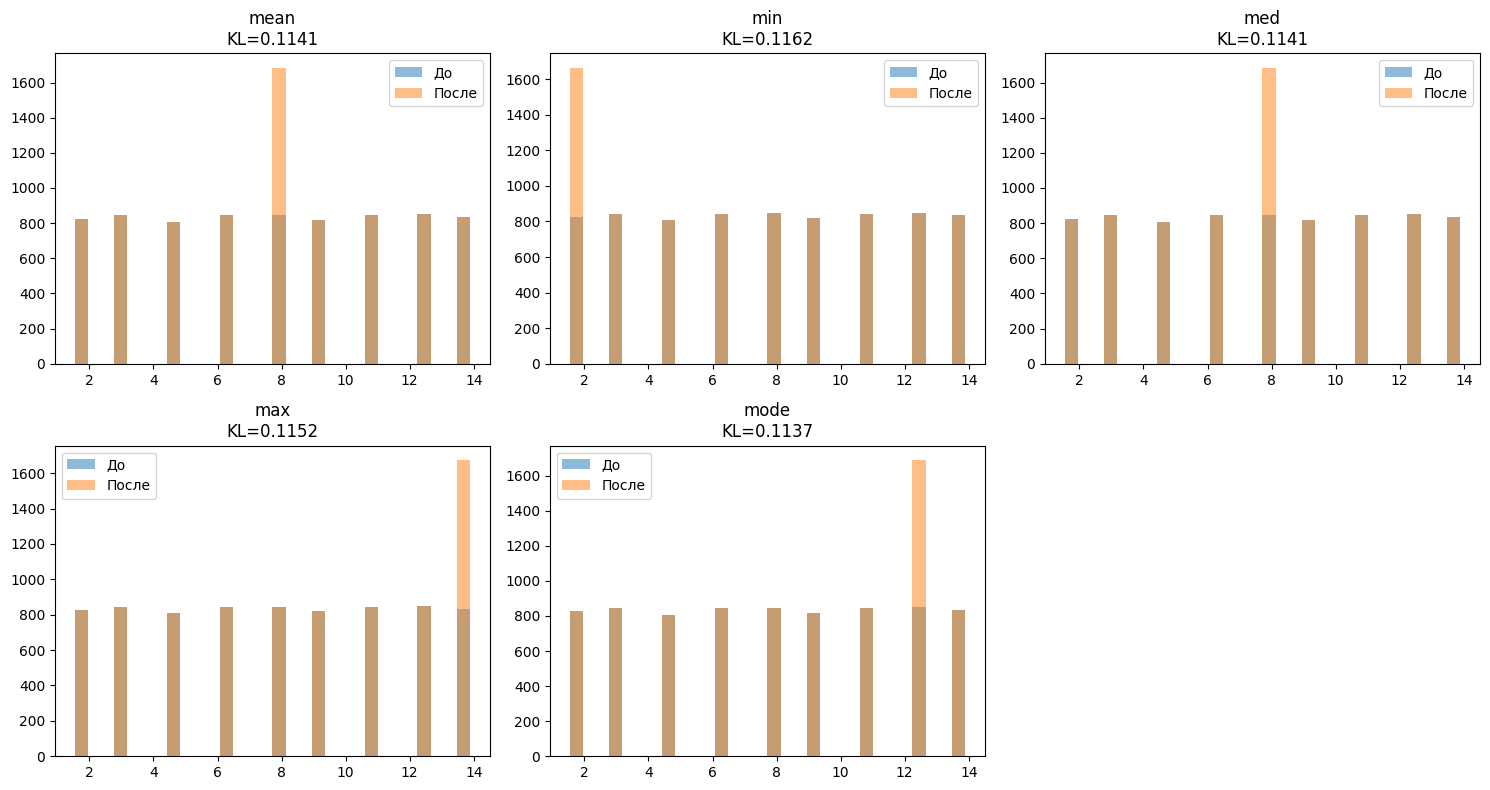

Статистические методы KL:
mean: 0.114066
min: 0.116151
med: 0.114066
max: 0.115205
mode: 0.113657


In [40]:
original = nan_col.dropna()

methods_stat = {
    'mean': nan_col.mean(),
    'min': nan_col.min(),
    'med': nan_col.median(),
    'max': nan_col.max(),
    'mode': nan_col.mode()[0]
}

kl_stat = {}

plt.figure(figsize=(15, 8))
for i, (name, value) in enumerate(methods_stat.items(), 1):
    filled = nan_col.fillna(value)
    kl = simple_kl(original, filled)
    kl_stat[name] = kl
    
    plt.subplot(2, 3, i)
    plt.hist(original, bins=30, alpha=0.5, label='До')
    plt.hist(filled, bins=30, alpha=0.5, label='После')
    plt.title(f'{name}\nKL={kl:.4f}')
    plt.legend()

plt.tight_layout()
plt.show()

print("Статистические методы KL:")
for name, kl in kl_stat.items():
    print(f"{name}: {kl:.6f}")

Для поиска наиболее оптимального значения проведено аналогичное исследование, применяющее ML-методы MICE и KNN.

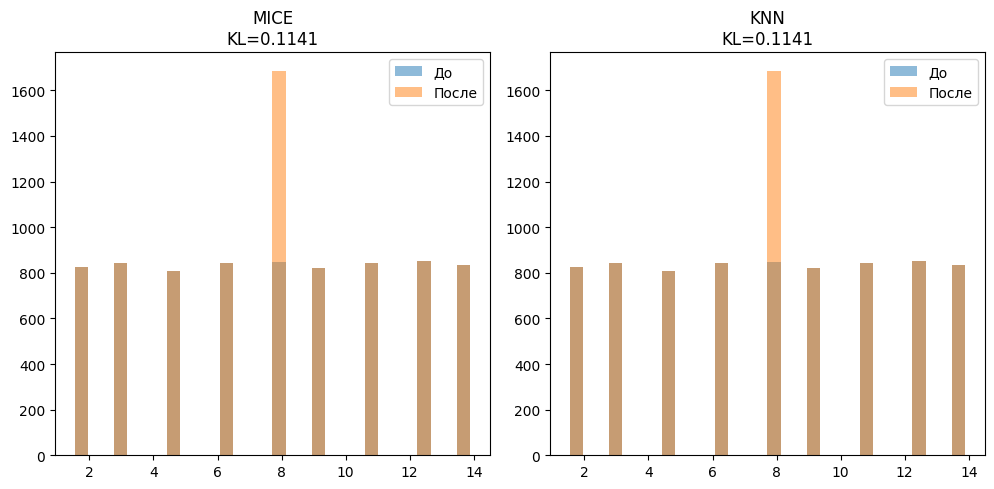

ML методы KL:
MICE: 0.114066
KNN: 0.114066


In [41]:
X = nan_col.values.reshape(-1, 1)

methods_ml = {
    'MICE': IterativeImputer(random_state=RANDOM_STATE),
    'KNN': KNNImputer(n_neighbors=7)
}

kl_ml = {}

plt.figure(figsize=(15, 5))
for i, (name, imp) in enumerate(methods_ml.items(), 1):
    filled_2d = imp.fit_transform(X)
    filled = filled_2d.flatten()
    kl = simple_kl(original, filled)
    kl_ml[name] = kl
    
    plt.subplot(1, 3, i)
    plt.hist(original, bins=30, alpha=0.5, label='До')
    plt.hist(filled, bins=30, alpha=0.5, label='После')
    plt.title(f'{name}\nKL={kl:.4f}')
    plt.legend()

plt.tight_layout()
plt.show()

print("ML методы KL:")
for name, kl in kl_ml.items():
    print(f"{name}: {kl:.6f}")

Результаты методов объединены для удобства.

In [42]:
all_methods = {**kl_stat, **kl_ml}

print("Все методы:")
for name, kl in sorted(all_methods.items(), key=lambda x: x[1]):
    print(f"{name}: {kl:.6f}")

Все методы:
mode: 0.113657
mean: 0.114066
med: 0.114066
MICE: 0.114066
KNN: 0.114066
max: 0.115205
min: 0.116151


Самый подходящий метод заполнения - заполнение моды, потому что данный способ получил наименьшее значение KL-дивергенции (меньше расстояние - больше схожесть исходного и изменённого столбцов). На основе этого вывода все пропущенные значения в данных заполняются модой.

In [43]:
X_train['Скорость перехода через портал'].fillna(methods_stat['mode'], inplace=True)
X_test['Скорость перехода через портал'].fillna(X_test['Скорость перехода через портал'].mode()[0], inplace=True)
X_train

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи
9653,6.175,9.25992,29761.608,241.572139,8790.141,246.015,246.015,772.240,2.515,13.347,34.254,0.678,0.991,Выше среднего
2269,2.088,3.08664,3152.420,141.591057,6838.435,23.699,23.699,517.051,1.206,6.466,16.754,0.156,0.959,Слабый
11461,5.140,7.71660,21625.519,201.516623,8471.841,175.228,175.228,682.640,2.087,10.987,23.849,0.472,0.998,Выше среднего
9349,8.206,12.34656,50993.086,323.317950,9305.741,437.978,437.978,901.076,3.586,18.272,58.585,1.160,0.989,Сильный
5427,1.138,12.34656,748.284,141.564982,6642.099,7.624,7.624,468.577,1.115,6.029,8.163,0.093,0.973,Слабый
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,8.206,12.34656,50989.676,323.300567,9292.800,437.925,437.925,915.018,3.607,18.693,60.083,1.189,0.998,Сильный
5191,8.206,12.34656,50993.686,323.319312,9306.729,438.021,438.021,933.160,3.589,18.621,61.190,1.211,0.972,Сильный
5390,9.300,12.34656,72759.686,372.841179,9751.200,644.872,644.872,1089.292,4.526,22.961,90.760,1.797,0.973,Сильный
860,6.175,9.25992,29797.053,241.615179,8842.649,246.362,246.362,779.989,2.497,13.129,34.453,0.682,0.953,Выше среднего


## 1.5. <a id='toc1_5_'></a>[Кодирование категориальных признаков](#toc0_)

Так как категориальные признаки имеют иерархию, к ним был применён способ кодировки Label Encoding - каждому текстовому значению было присвоено числовое значение.

In [44]:
labels = {
    'Слабый': 0,
    'Ниже среднего': 1, 
    'Выше среднего': 2,
    'Сильный': 3
}

X_train['Тип Вектора Мощи'] = X_train['Тип Вектора Мощи'].map(labels)
X_test['Тип Вектора Мощи'] = X_test['Тип Вектора Мощи'].map(labels)

X_train

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи
9653,6.175,9.25992,29761.608,241.572139,8790.141,246.015,246.015,772.240,2.515,13.347,34.254,0.678,0.991,2
2269,2.088,3.08664,3152.420,141.591057,6838.435,23.699,23.699,517.051,1.206,6.466,16.754,0.156,0.959,0
11461,5.140,7.71660,21625.519,201.516623,8471.841,175.228,175.228,682.640,2.087,10.987,23.849,0.472,0.998,2
9349,8.206,12.34656,50993.086,323.317950,9305.741,437.978,437.978,901.076,3.586,18.272,58.585,1.160,0.989,3
5427,1.138,12.34656,748.284,141.564982,6642.099,7.624,7.624,468.577,1.115,6.029,8.163,0.093,0.973,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,8.206,12.34656,50989.676,323.300567,9292.800,437.925,437.925,915.018,3.607,18.693,60.083,1.189,0.998,3
5191,8.206,12.34656,50993.686,323.319312,9306.729,438.021,438.021,933.160,3.589,18.621,61.190,1.211,0.972,3
5390,9.300,12.34656,72759.686,372.841179,9751.200,644.872,644.872,1089.292,4.526,22.961,90.760,1.797,0.973,3
860,6.175,9.25992,29797.053,241.615179,8842.649,246.362,246.362,779.989,2.497,13.129,34.453,0.682,0.953,2


## 1.6. <a id='toc1_6_'></a>[Детекция выбросов и аномалий в данных](#toc0_)

Для удобства дальшейшей работы и единообразия выполняемых действий столбцы признаков и целевого признака объединены в один датасет.

In [45]:
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

Для поиска выбросов были рассмотрены два статистических способа - поиск через квантили (IQR) и через значение Robust z-score. Эти методы были реализованы в функциях, которые находят индексы выбросов.

In [46]:
def find_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (column < lower_bound) | (column > upper_bound)

def find_outliers_robust_zscore(column, threshold=3):
    median = column.median()
    mad = stats.median_abs_deviation(column)
    if mad == 0:
        return pd.Series([False] * len(column), index=column.index)
    robust_z = np.abs(0.6745 * (column - median) / mad)
    return robust_z > threshold

Для каждого столбца был выполнен поиск аномалий, а так же построена диаграмма ящик с усами и гистограмма. Ящик с усами позволяет выявить наличие выбросов, а гистограмма визуализирует распределение.

Вектор Мощи: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Скорость перехода через портал: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Приток Силы Потока: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Ритм магического ядра: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Поток Энергий: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Сила Левого Потока: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Сила Правого Потока: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Пламя Стихий: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Приток давления Выдоха Истока: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Давление выдоха Истока: IQR выбросов - 0, Robust Z-score выбросов - 0, Общих - 0
Печать Чародея: IQR выбросов - 338, Robust Z-score выбросов - 921, Общих - 338
Эмульсия Истока: IQR выбросов - 0, Robust Z-score выбросов - 921, Общих - 0
Дыхание Истока: IQR выбросов - 0, Robust Z-score выбросов - 0,

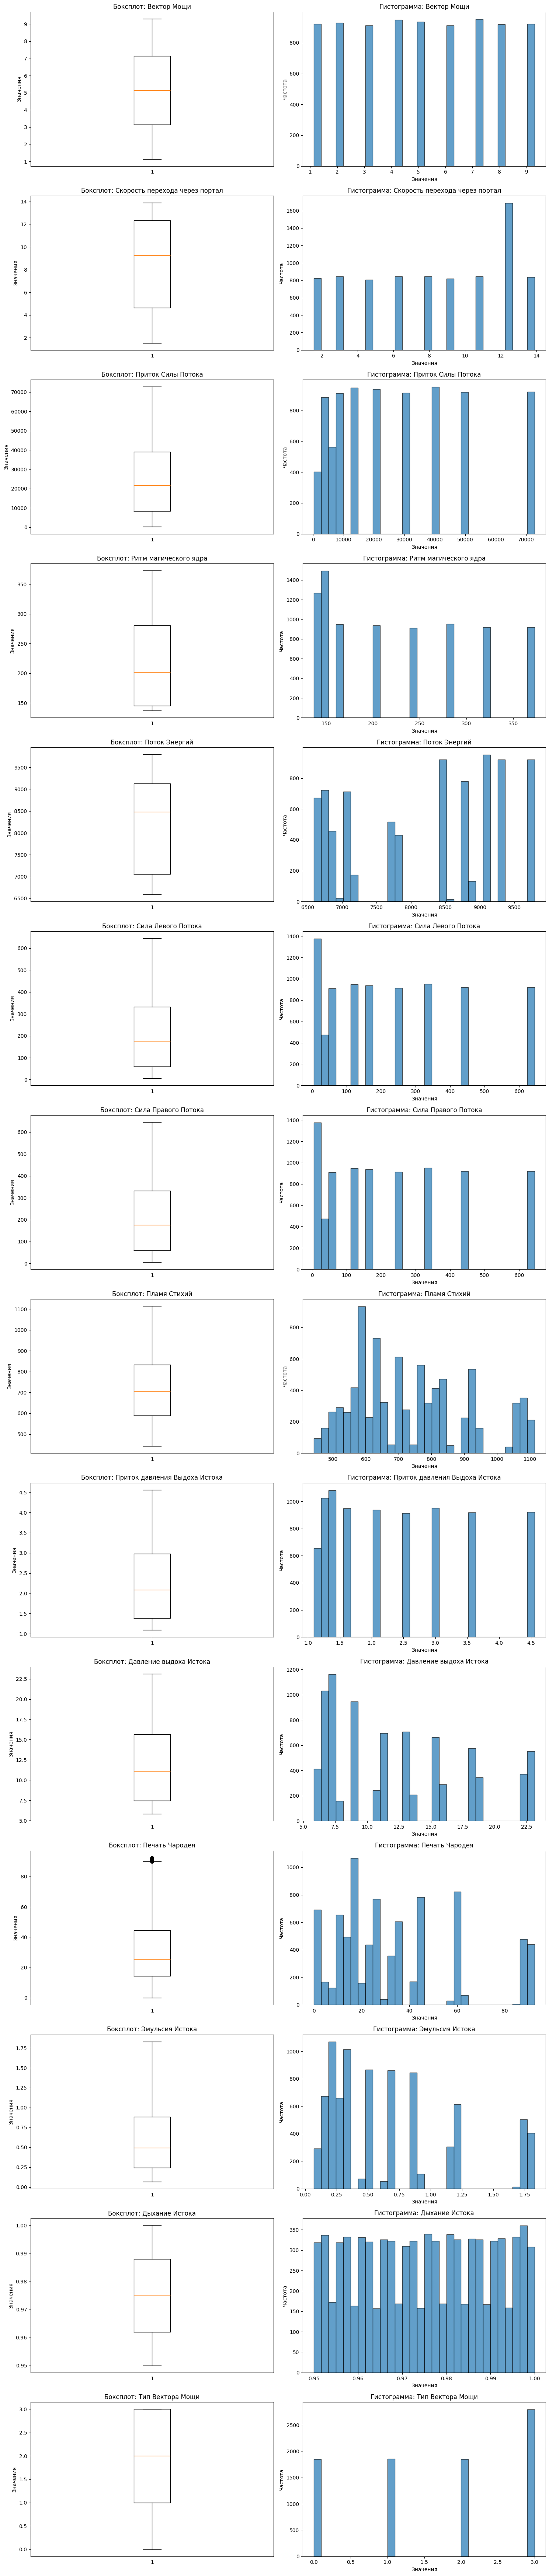

In [47]:
cols = df_train.drop('Гармония Бессмертия', axis=1).columns
outliers_dict = {}

fig, axes = plt.subplots(len(cols), 2, figsize=(15, 5*len(cols)))
if len(cols) == 1:
    axes = [[axes[0], axes[1]]]
else:
    axes = axes.reshape(len(cols), 2)

for i, col in enumerate(cols):
    axes[i, 0].boxplot(df_train[col].dropna())
    axes[i, 0].set_title(f'Боксплот: {col}')
    axes[i, 0].set_ylabel('Значения')

    axes[i, 1].hist(df_train[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
    axes[i, 1].set_title(f'Гистограмма: {col}')
    axes[i, 1].set_xlabel('Значения')
    axes[i, 1].set_ylabel('Частота')

    iqr_outliers = find_outliers_iqr(df_train[col])
    robust_outliers = find_outliers_robust_zscore(df_train[col], threshold=3)

    common_outliers = iqr_outliers & robust_outliers
    outliers_dict[col] = set(df_train[common_outliers].index.tolist())
    
    print(f"{col}: IQR выбросов - {iqr_outliers.sum()}, Robust Z-score выбросов - {robust_outliers.sum()}, Общих - {len(outliers_dict[col])}")

plt.tight_layout()
plt.show()

Из данных были удалены строки с выбросами, всего их обнаружено 338, только столбец "Печать Чародея" обладал выбросами.

In [48]:
all_outlier_indices = set()
for col, indices in outliers_dict.items():
    all_outlier_indices.update(indices)

df_train = df_train.drop(index=list(all_outlier_indices))
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8015 entries, 9653 to 7270
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     8015 non-null   float64
 1   Скорость перехода через портал  8015 non-null   float64
 2   Приток Силы Потока              8015 non-null   float64
 3   Ритм магического ядра           8015 non-null   float64
 4   Поток Энергий                   8015 non-null   float64
 5   Сила Левого Потока              8015 non-null   float64
 6   Сила Правого Потока             8015 non-null   float64
 7   Пламя Стихий                    8015 non-null   float64
 8   Приток давления Выдоха Истока   8015 non-null   float64
 9   Давление выдоха Истока          8015 non-null   float64
 10  Печать Чародея                  8015 non-null   float64
 11  Эмульсия Истока                 8015 non-null   float64
 12  Дыхание Истока                  8015

Для поиска аномалий были выбраны ML-методы IForest, OCSVM и DBSCAN. Каждая модель обучается и делает предположение о наличии аномалий.

In [49]:
X = df_train.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Данные для поиска аномалий: {X_scaled.shape}")

models = {
    'Isolation Forest': IForest(contamination=0.1, random_state=42),
    'One-class SVM': OCSVM(contamination=0.1)
}

anomalies_dict = {}

for name, model in models.items():
    model.fit(X_scaled)
    predictions = model.predict(X_scaled)
    anomalies = predictions == 1
    anomalies_dict[name] = set(np.where(anomalies)[0])
    print(f"{name}: найдено {anomalies.sum()} аномалий")

dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

dbscan_anomalies = dbscan_labels == -1
anomalies_dict['DBSCAN'] = set(np.where(dbscan_anomalies)[0])
print(f"DBSCAN: найдено {dbscan_anomalies.sum()} аномалий")

Данные для поиска аномалий: (8015, 15)
Isolation Forest: найдено 802 аномалий
One-class SVM: найдено 802 аномалий
DBSCAN: найдено 458 аномалий


Найденые аномалии были визуализированы на всех данных (для понижения размерности признакового пространства применён алгоритм PCA).

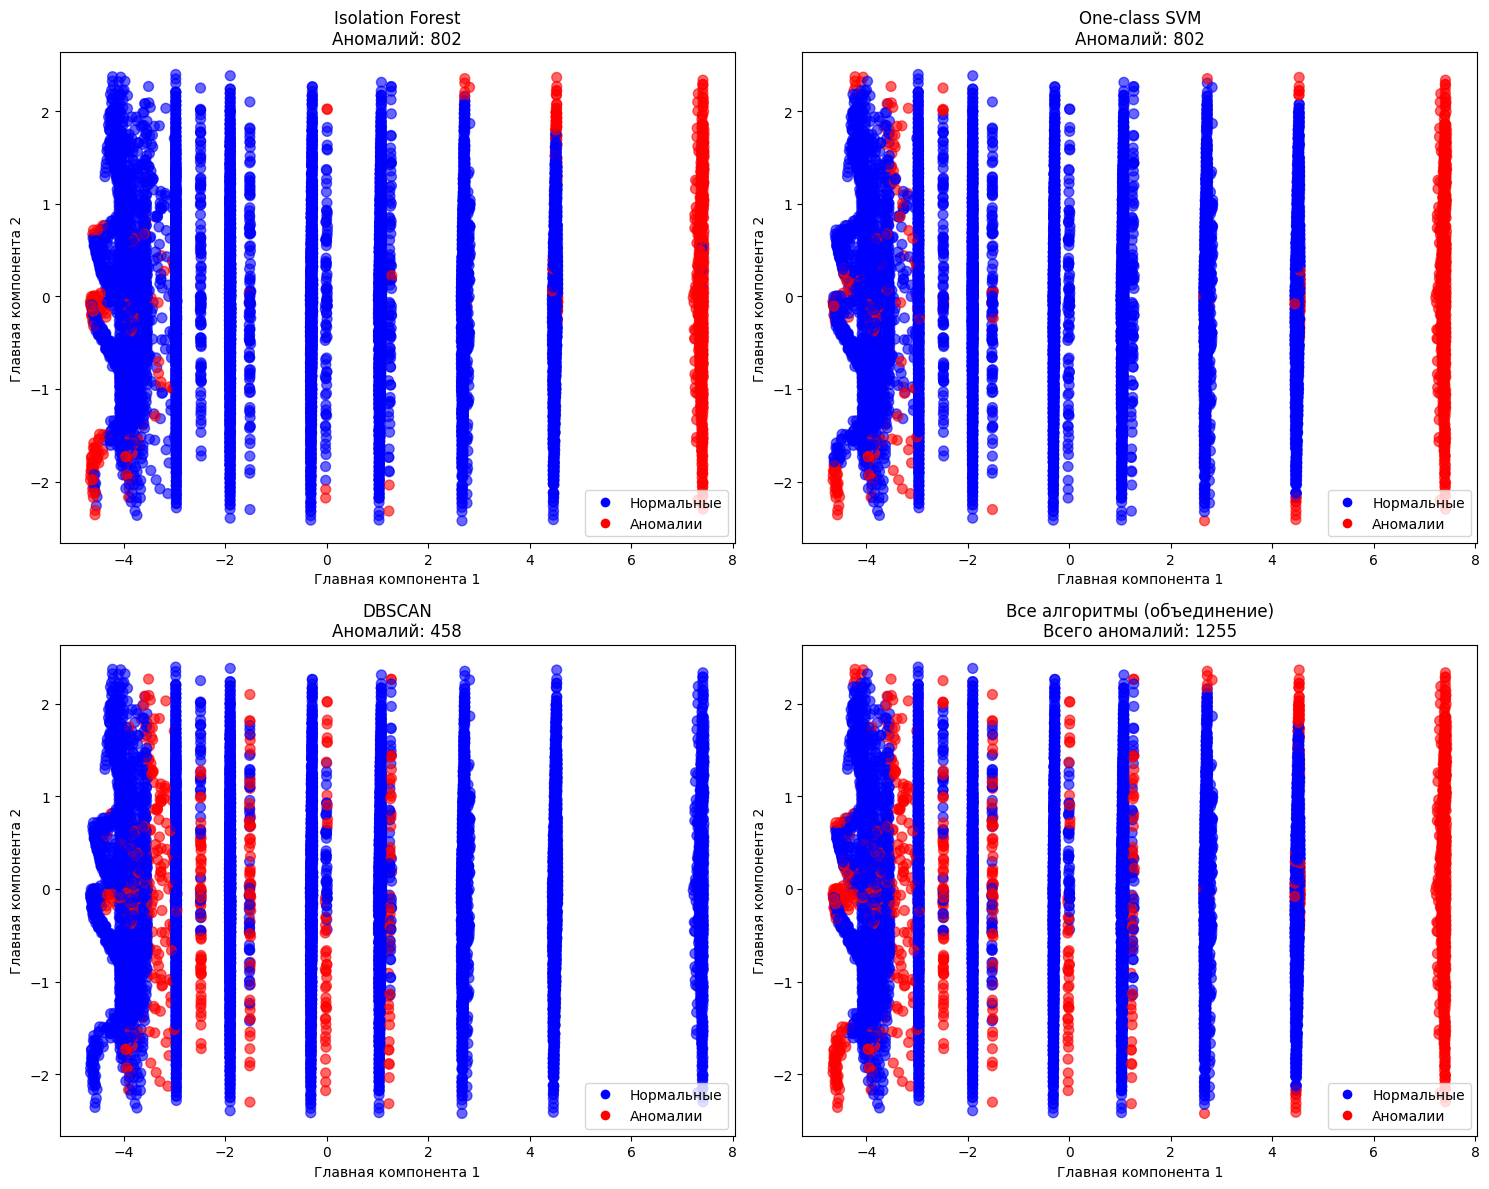

In [50]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, (name, anomalies_indices) in enumerate(anomalies_dict.items()):
    colors = ['blue' if i not in anomalies_indices else 'red' for i in range(len(X_pca))]
    
    axes[i].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=50)
    axes[i].set_title(f'{name}\nАномалий: {len(anomalies_indices)}')
    axes[i].set_xlabel('Главная компонента 1')
    axes[i].set_ylabel('Главная компонента 2')

    normal_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Нормальные')
    anomaly_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Аномалии')
    axes[i].legend(handles=[normal_patch, anomaly_patch])

all_anomaly_indices = set()
for indices in anomalies_dict.values():
    all_anomaly_indices.update(indices)

colors = ['blue' if i not in all_anomaly_indices else 'red' for i in range(len(X_pca))]
axes[3].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=50)
axes[3].set_title(f'Все алгоритмы (объединение)\nВсего аномалий: {len(all_anomaly_indices)}')
axes[3].set_xlabel('Главная компонента 1')
axes[3].set_ylabel('Главная компонента 2')
axes[3].legend(handles=[normal_patch, anomaly_patch])

plt.tight_layout()
plt.show()

Агомалии к удалению - это пересечение найденых аномалий у всех алгоритмов. Для визуализации построены гистограммы.

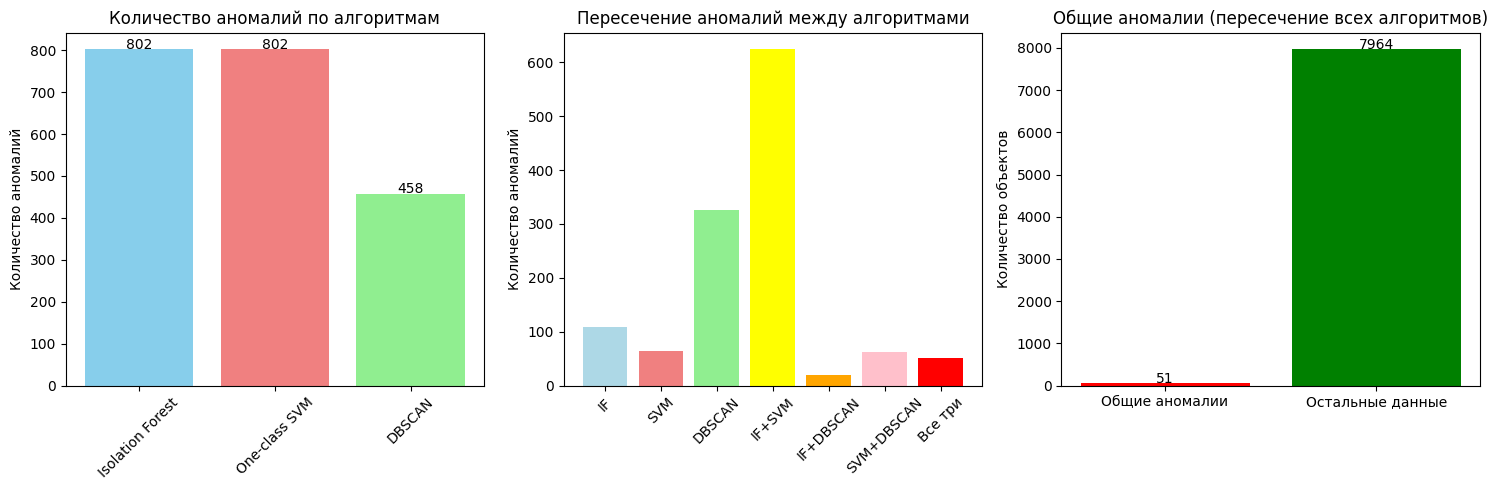

Общих аномалий (пересечение всех алгоритмов): 51


In [51]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
algorithm_names = list(anomalies_dict.keys())
anomaly_counts = [len(indices) for indices in anomalies_dict.values()]
plt.bar(algorithm_names, anomaly_counts, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Количество аномалий по алгоритмам')
plt.ylabel('Количество аномалий')
plt.xticks(rotation=45)

for i, count in enumerate(anomaly_counts):
    plt.text(i, count + 2, str(count), ha='center')

plt.subplot(1, 3, 2)
if_anomalies = anomalies_dict['Isolation Forest']
svm_anomalies = anomalies_dict['One-class SVM']
dbscan_anomalies = anomalies_dict['DBSCAN']

only_if = len(if_anomalies - svm_anomalies - dbscan_anomalies)
only_svm = len(svm_anomalies - if_anomalies - dbscan_anomalies)
only_dbscan = len(dbscan_anomalies - if_anomalies - svm_anomalies)
if_svm = len(if_anomalies & svm_anomalies - dbscan_anomalies)
if_dbscan = len(if_anomalies & dbscan_anomalies - svm_anomalies)
svm_dbscan = len(svm_anomalies & dbscan_anomalies - if_anomalies)
all_three = len(if_anomalies & svm_anomalies & dbscan_anomalies)

intersection_data = [only_if, only_svm, only_dbscan, if_svm, if_dbscan, svm_dbscan, all_three]
intersection_labels = ['IF', 'SVM', 'DBSCAN', 'IF+SVM', 'IF+DBSCAN', 'SVM+DBSCAN', 'Все три']

plt.bar(intersection_labels, intersection_data, color=['lightblue', 'lightcoral', 'lightgreen', 'yellow', 'orange', 'pink', 'red'])
plt.title('Пересечение аномалий между алгоритмами')
plt.ylabel('Количество аномалий')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
common_anomalies = if_anomalies & svm_anomalies & dbscan_anomalies
categories = ['Общие аномалии', 'Остальные данные']
counts = [len(common_anomalies), len(X_scaled) - len(common_anomalies)]
plt.bar(categories, counts, color=['red', 'green'])
plt.title('Общие аномалии (пересечение всех алгоритмов)')
plt.ylabel('Количество объектов')

for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center')

plt.tight_layout()
plt.show()

print(f"Общих аномалий (пересечение всех алгоритмов): {len(common_anomalies)}")

Из набора данных удалены найденные аномалии в количестве 51 строка.

In [52]:
anomaly_df_indices = [df_train.index[i] for i in common_anomalies]
df_train.drop(index=anomaly_df_indices, inplace=True)

Данные обратно разделяются для дальнейших пребразований.

In [53]:
X_train = df_train.drop('Гармония Бессмертия', axis=1)
y_train = df_train['Гармония Бессмертия']
X_test = df_test.drop('Гармония Бессмертия', axis=1)
y_test = df_test['Гармония Бессмертия']

## 1.7. <a id='toc1_7_'></a>[Подведение итогов раздела 1](#toc0_)
<!-- А таких разделах обычно подытоживается вся информация о тех действиях, которые вы делали в разделе -->

Данные были загружены, неинформативные (мало уникальных данных, много пропусков) столбцы сразу были исключены, выборка поделена на тренировочную и тестовую (70%/30%), пропущенные значения заполнены модой, категориальные столбцы были закодированы числами (ручной LabelEncoding), однаруженные выбросы и аномалии удалены из данных.

# 2. <a id='toc2_'></a>[Генерация новых признаков](#toc0_)

## 2.1. <a id='toc2_1_'></a>[Корреляционный анализ входных признаков (построение тепловых карт корреляции)](#toc0_)

Визуализация тепловой карты корреляции может помочь выявить зависимости в данных.

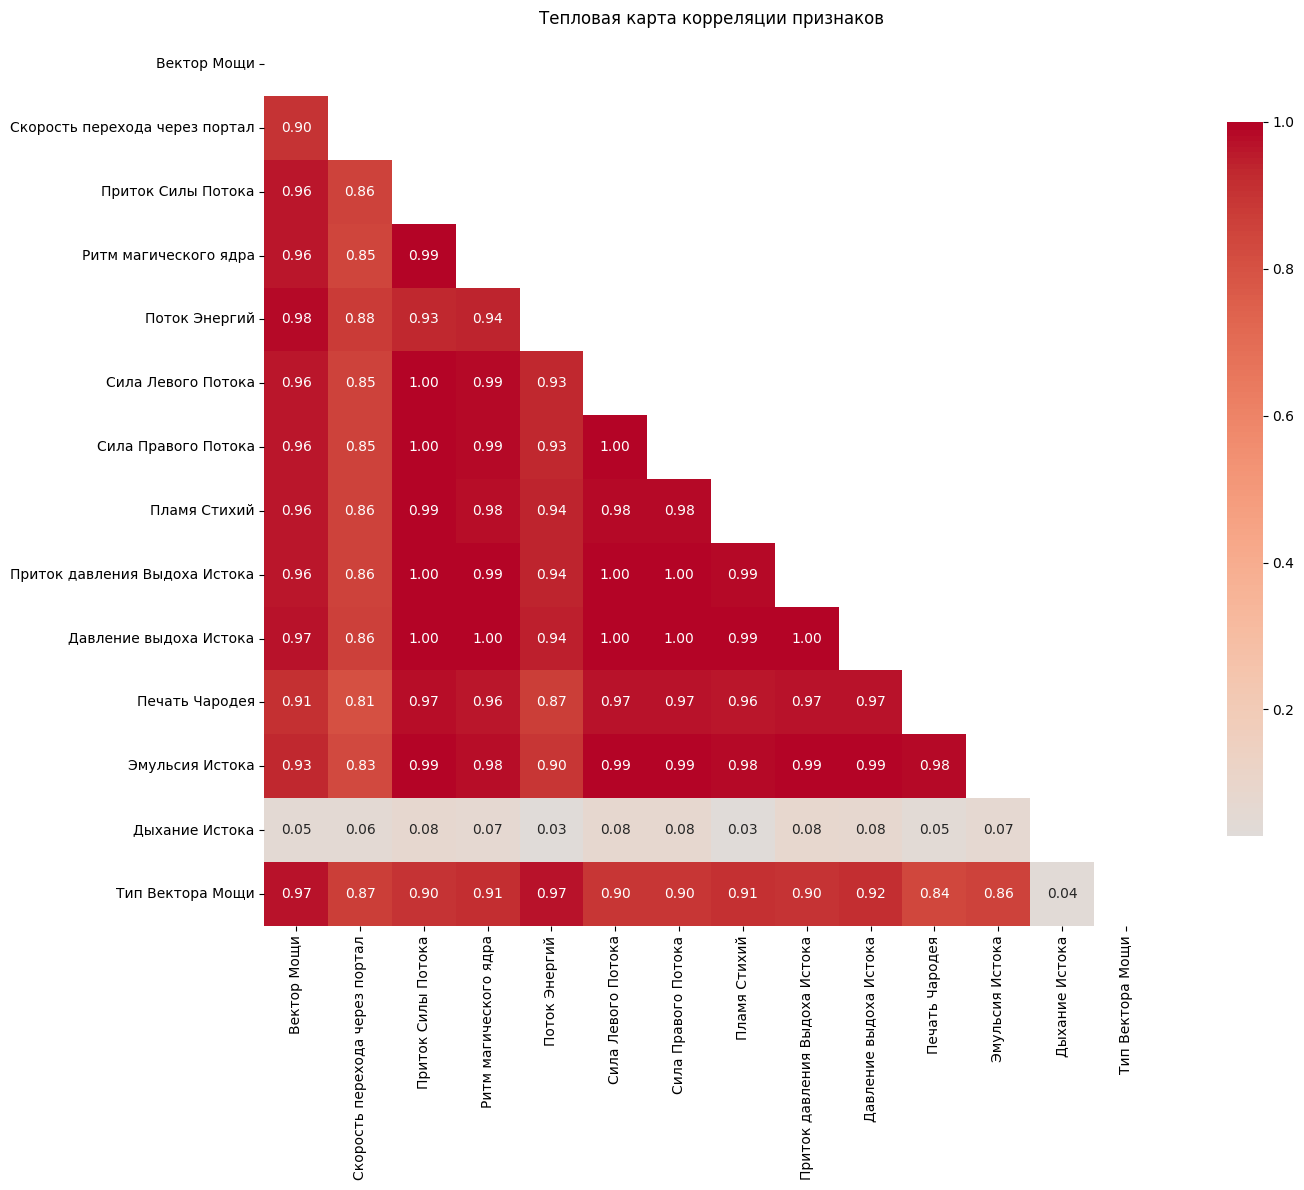

In [54]:
plt.figure(figsize=(16, 12))

correlation_matrix = X_train.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Тепловая карта корреляции признаков')
plt.tight_layout()
plt.show()

strong_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            strong_corr_pairs.append((col1, col2, corr_value))

В данных есть очевидная проблема мультиколлинеарности - многие столбцы имеют значение корреляции больше 0.9.

## 2.2. <a id='toc2_2_'></a>[Исправление проблемы мультиколлинеарности в данных](#toc0_)

Для ранее описаных формул создана функция, создающая новые столбцы и удаляющая использованные столбцы (только те, которые дали линейную зависимость).

In [55]:
def create_magic_features(df):
    df_transformed = df.copy()
    df_transformed['Сумма потоков'] = df_transformed['Сила Левого Потока'] + df_transformed['Сила Правого Потока']
    df_transformed['Общая сила потоков'] = df_transformed['Сумма потоков'] + df_transformed['Приток Силы Потока']
    df_transformed['Общая сила ядра'] = df_transformed['Ритм магического ядра'] * df_transformed['Приток Силы Потока']
    df_transformed['Общее давление'] = df_transformed['Приток давления Выдоха Истока'] + df_transformed['Давление выдоха Истока']
    df_transformed['Магическая производительность'] = (df_transformed['Скорость перехода через портал'] / 
                                                     (df_transformed['Эмульсия Истока'] + 1e-8))
    df_transformed['Эффективность ядра'] = (df_transformed['Общая сила ядра'] / 
                                          (df_transformed['Эмульсия Истока'] + 1e-8))
    
    return df_transformed.drop(['Сила Левого Потока', 'Сила Правого Потока', 'Сумма потоков', 'Приток Силы Потока', 'Приток давления Выдоха Истока', 'Давление выдоха Истока'], axis=1)

Функция генерации новых признаков применена на данных.

In [56]:
X_train = create_magic_features(X_train)
X_test = create_magic_features(X_test)
X_train

,Вектор Мощи,Скорость перехода через портал,Ритм магического ядра,Поток Энергий,Пламя Стихий,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Общая сила потоков,Общая сила ядра,Общее давление,Магическая производительность,Эффективность ядра
9653,6.175,9.25992,241.572139,8790.141,772.240,34.254,0.678,0.991,2,30253.638,7.189575e+06,15.862,13.657699,1.060409e+07
2269,2.088,3.08664,141.591057,6838.435,517.051,16.754,0.156,0.959,0,3199.818,4.463545e+05,7.672,19.786153,2.861246e+06
11461,5.140,7.71660,201.516623,8471.841,682.640,23.849,0.472,0.998,2,21975.975,4.357902e+06,13.074,16.348728,9.232842e+06
9349,8.206,12.34656,323.317950,9305.741,901.076,58.585,1.160,0.989,3,51869.042,1.648698e+07,21.858,10.643586,1.421291e+07
10451,3.144,4.62996,145.218759,7056.224,572.545,11.779,0.233,0.994,1,8496.259,1.216298e+06,8.862,19.871072,5.220162e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,2.088,3.08664,145.007435,6812.997,515.378,0.000,0.143,0.974,0,3657.722,5.217927e+05,7.834,21.584894,3.648900e+06
11284,8.206,12.34656,323.300567,9292.800,915.018,60.083,1.189,0.998,3,51865.526,1.648499e+07,22.300,10.383986,1.386458e+07
5191,8.206,12.34656,323.319312,9306.729,933.160,61.190,1.211,0.972,3,51869.728,1.648724e+07,22.210,10.195343,1.361457e+07
860,6.175,9.25992,241.615179,8842.649,779.989,34.453,0.682,0.953,2,30289.777,7.199420e+06,15.626,13.577595,1.055633e+07


Для прорверки на избавление от мультиколлинеарности повторный просмотр карты корреляции.

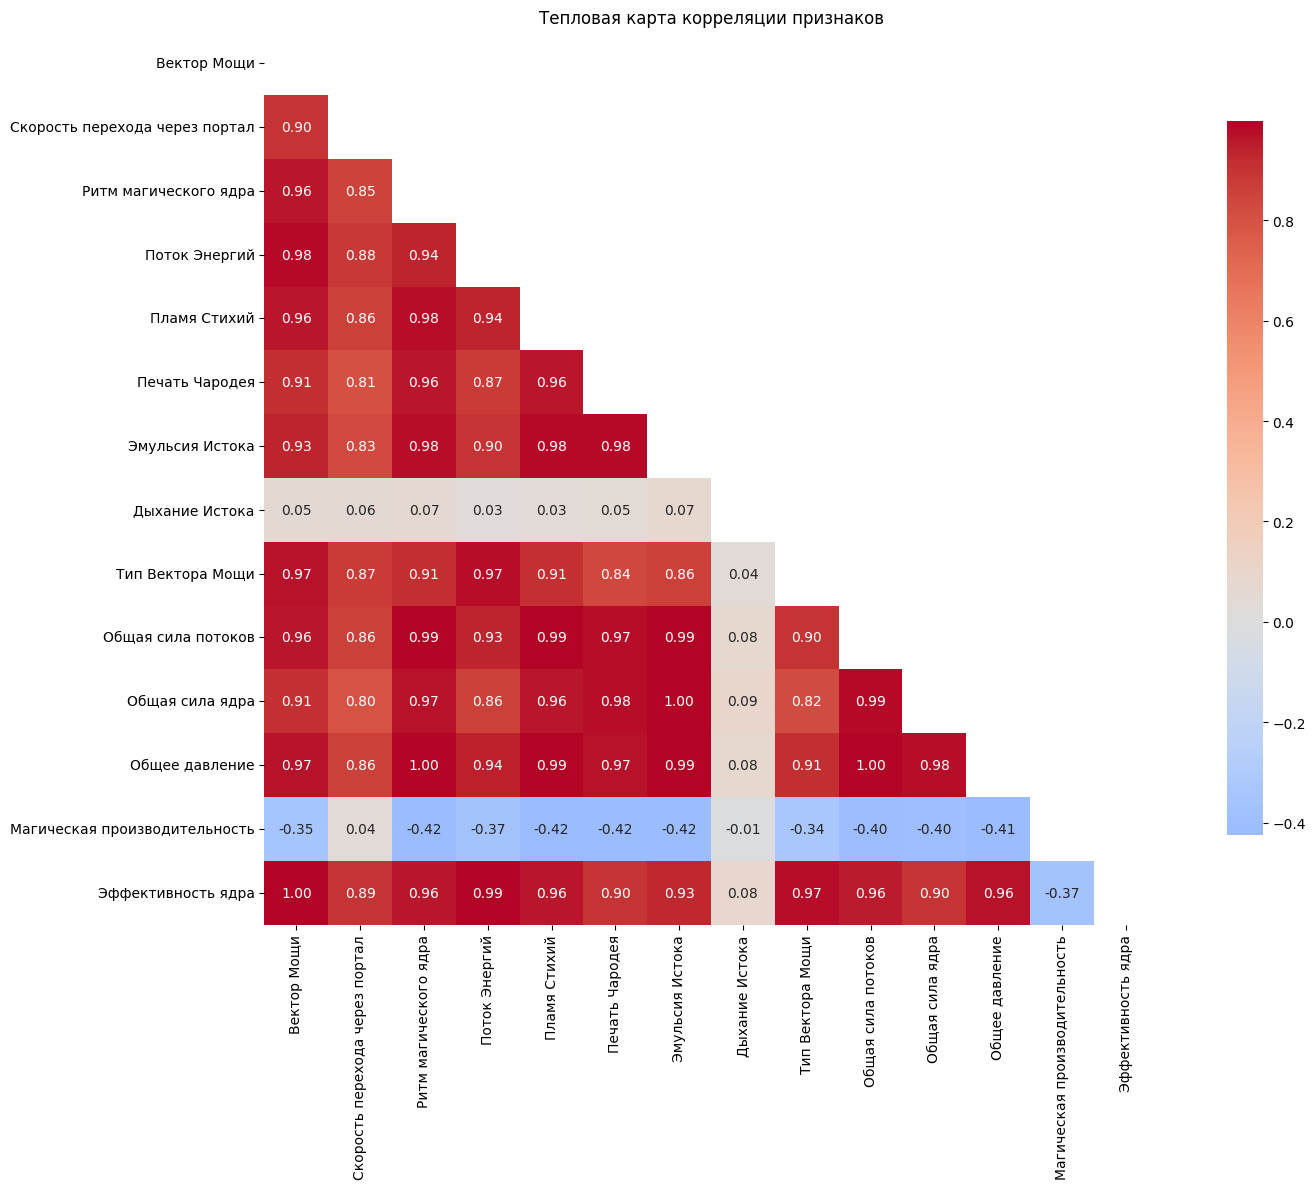

In [57]:
plt.figure(figsize=(16, 12))

correlation_matrix = X_train.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Тепловая карта корреляции признаков')
plt.tight_layout()
plt.show()

strong_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            strong_corr_pairs.append((col1, col2, corr_value))

Далее были применены два способа решения проблемы мультиколлинеарности - удаление столбцов, сильно кореллирующих между собой, а так же алгоритм понижения размеронсти PCA.

In [58]:
X_train_drop = X_train.drop(['Общая сила ядра', 'Эмульсия Истока', 'Скорость перехода через портал', 'Ритм магического ядра'], axis=1)
X_test_drop = X_test.drop(['Общая сила ядра', 'Эмульсия Истока', 'Скорость перехода через портал', 'Ритм магического ядра'], axis=1)
X_train_drop

,Вектор Мощи,Поток Энергий,Пламя Стихий,Печать Чародея,Дыхание Истока,Тип Вектора Мощи,Общая сила потоков,Общее давление,Магическая производительность,Эффективность ядра
9653,6.175,8790.141,772.240,34.254,0.991,2,30253.638,15.862,13.657699,1.060409e+07
2269,2.088,6838.435,517.051,16.754,0.959,0,3199.818,7.672,19.786153,2.861246e+06
11461,5.140,8471.841,682.640,23.849,0.998,2,21975.975,13.074,16.348728,9.232842e+06
9349,8.206,9305.741,901.076,58.585,0.989,3,51869.042,21.858,10.643586,1.421291e+07
10451,3.144,7056.224,572.545,11.779,0.994,1,8496.259,8.862,19.871072,5.220162e+06
...,...,...,...,...,...,...,...,...,...,...
5734,2.088,6812.997,515.378,0.000,0.974,0,3657.722,7.834,21.584894,3.648900e+06
11284,8.206,9292.800,915.018,60.083,0.998,3,51865.526,22.300,10.383986,1.386458e+07
5191,8.206,9306.729,933.160,61.190,0.972,3,51869.728,22.210,10.195343,1.361457e+07
860,6.175,8842.649,779.989,34.453,0.953,2,30289.777,15.626,13.577595,1.055633e+07


Для определения количества достаточных компонент применяется метод локтя, визуализируемый на графике.

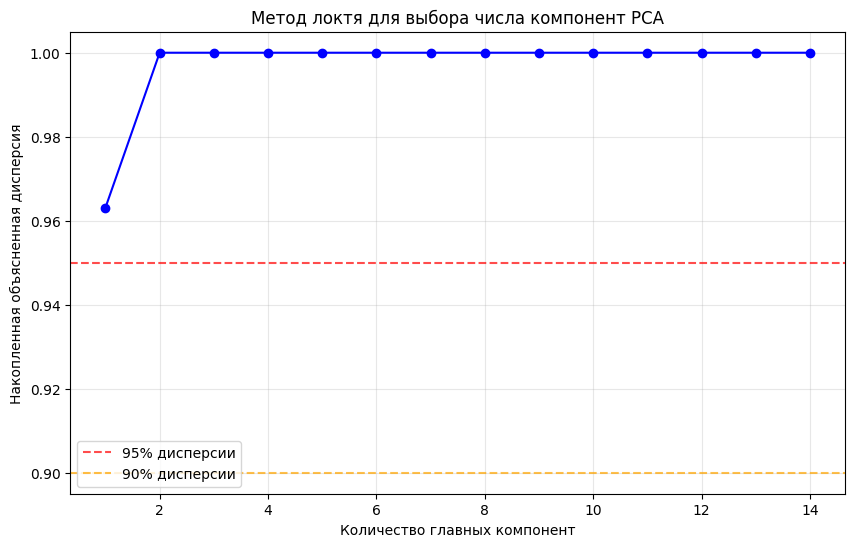

In [59]:
pca = PCA()
pca.fit(X_train)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% дисперсии')
plt.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% дисперсии')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('Метод локтя для выбора числа компонент PCA')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Так как по графику "локоть" даёт 2 компоненты, то PCA уменьшит признаковое пространство до 2 столбцов.

In [60]:
pca_final = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pd.DataFrame(pca_final.fit_transform(X_train))
X_test_pca = pd.DataFrame(pca_final.transform(X_test))

## 2.3. <a id='toc2_3_'></a>[Скалирование данных](#toc0_)

Так как данные не масштабированы - для каждого из вариантов данных (train/test, drop/pca) применяются три вида масштабирования - StandardScaler, MinMaxScaler, RobustScaler.

In [61]:
X_train_drop_orig = X_train_drop.copy()

drop_scaler_standard = StandardScaler()
X_train_drop_std = pd.DataFrame(drop_scaler_standard.fit_transform(X_train_drop.copy()))
X_test_drop_std = pd.DataFrame(drop_scaler_standard.transform(X_test_drop.copy()))

drop_scaler_minmax = MinMaxScaler()
X_train_drop_minmax = pd.DataFrame(drop_scaler_minmax.fit_transform(X_train_drop.copy()))
X_test_drop_minmax = pd.DataFrame(drop_scaler_minmax.transform(X_test_drop.copy()))

drop_scaler_robust = RobustScaler()
X_train_drop_robust = pd.DataFrame(drop_scaler_robust.fit_transform(X_train_drop.copy()))
X_test_drop_robust = pd.DataFrame(drop_scaler_robust.transform(X_test_drop.copy()))


X_train_pca_orig = X_train_pca.copy()

pca_scaler_standard = StandardScaler()
X_train_pca_std = pd.DataFrame(pca_scaler_standard.fit_transform(X_train_pca.copy()))
X_test_pca_std = pd.DataFrame(pca_scaler_standard.transform(X_test_pca.copy()))

pca_scaler_minmax = MinMaxScaler()
X_train_pca_minmax = pd.DataFrame(pca_scaler_minmax.fit_transform(X_train_pca.copy()))
X_test_pca_minmax = pd.DataFrame(pca_scaler_minmax.transform(X_test_pca.copy()))

pca_scaler_robust = RobustScaler()
X_train_pca_robust = pd.DataFrame(pca_scaler_robust.fit_transform(X_train_pca.copy()))
X_test_pca_robust = pd.DataFrame(pca_scaler_minmax.transform(X_test_pca.copy()))

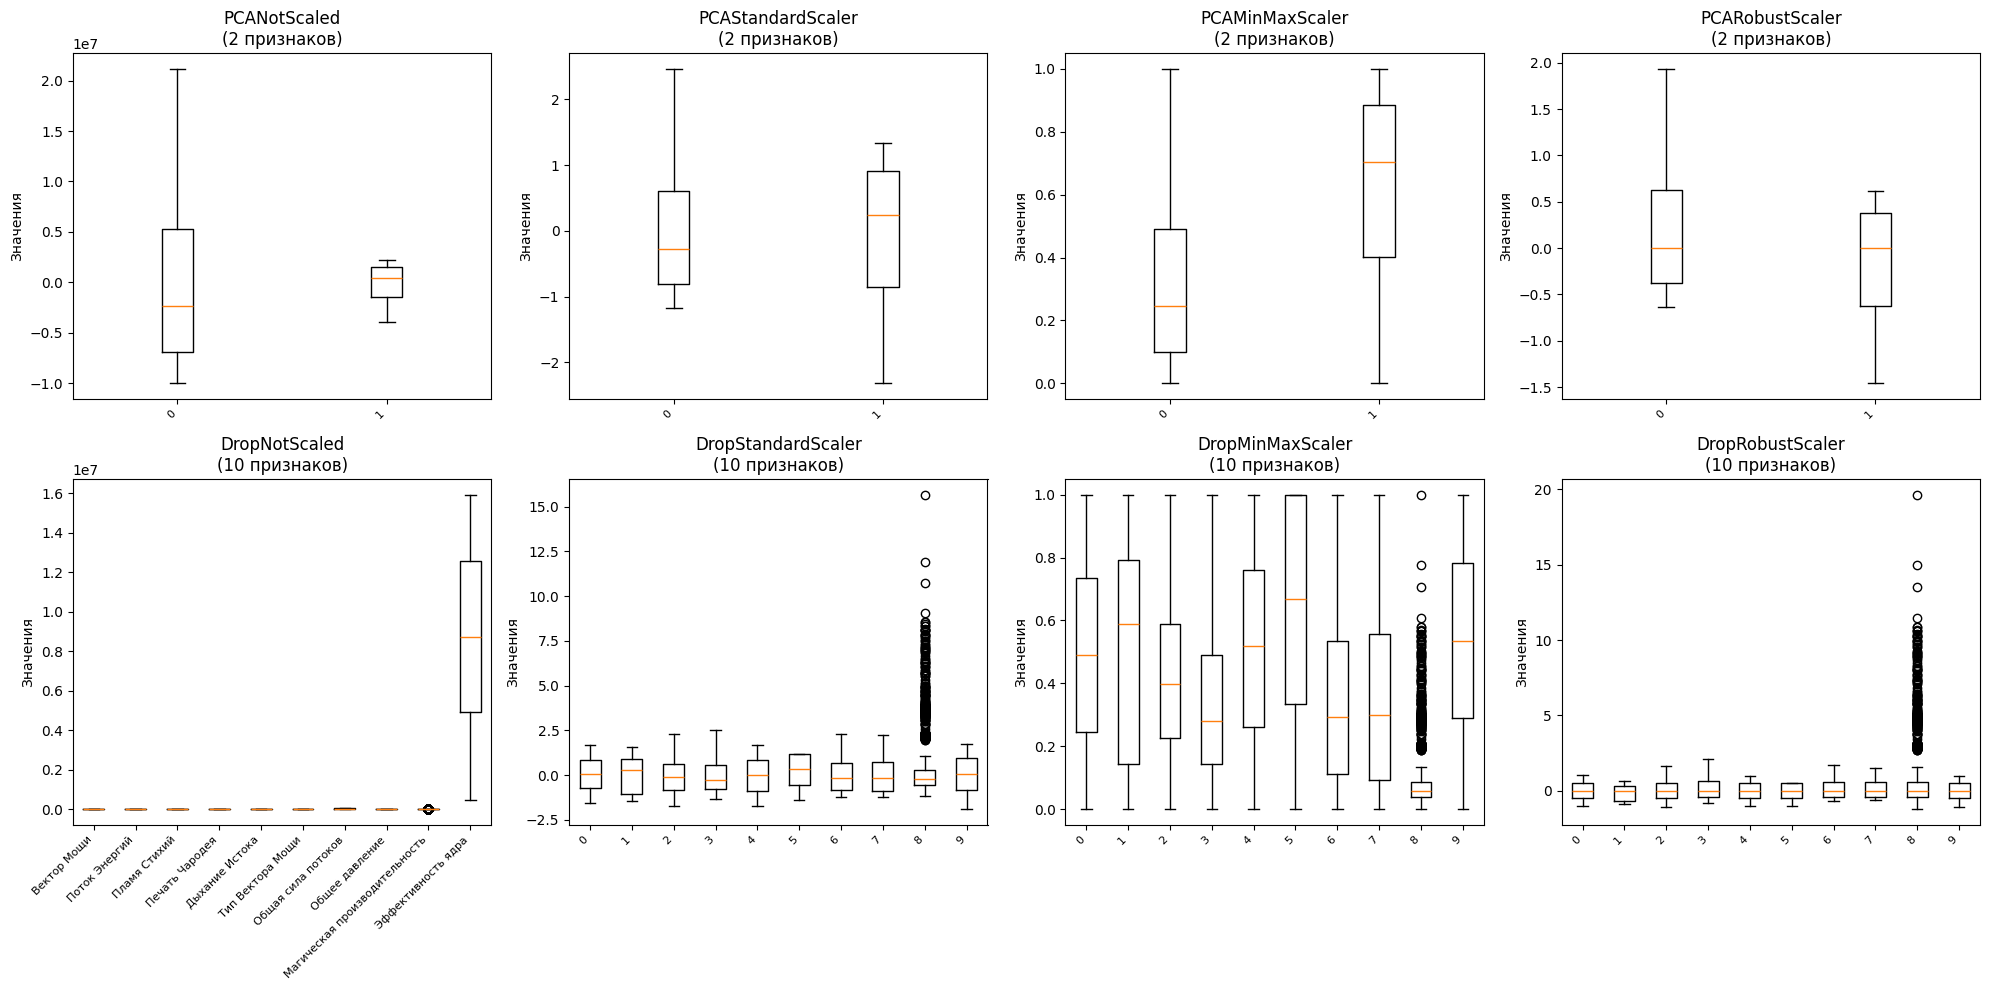

In [62]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

X_train_dict = {
    'PCANotScaled': X_train_pca_orig,
    'PCAStandardScaler': X_train_pca_std, 
    'PCAMinMaxScaler': X_train_pca_minmax,
    'PCARobustScaler': X_train_pca_robust,
    'DropNotScaled': X_train_drop_orig,
    'DropStandardScaler': X_train_drop_std, 
    'DropMinMaxScaler': X_train_drop_minmax,
    'DropRobustScaler': X_train_drop_robust
}

for idx, (name, data) in enumerate(X_train_dict.items()):
    axes[idx].boxplot(data.values)
    axes[idx].set_title(f'{name}\n({data.shape[1]} признаков)')
    axes[idx].set_xticklabels(data.columns, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Значения')

plt.tight_layout()
plt.show()

## 2.4. <a id='toc2_4_'></a>[Подведение итогов раздела 2](#toc0_)
<!-- А таких разделах обычно подытоживается вся информация о тех действиях, которые вы делали в разделе -->

Данные насыщенны новыми столбцами, созданными через описанные формулы, а признаковое пространство уменьшено двумя способами - удаление столбцов с высокой корреляцией и алгоритм PCA. Каждый вариант данных был масштабирован тремя разными способами. В результате получены 8 вариантов тренировочных и тестовых данных.

# 3. <a id='toc3_'></a>[Выбор моделей ML и метрик](#toc0_)

Для дальнейшей работы были выбраны 5 алгоритмов.

| Алгоритм | Сложность обучения | Сложность предсказания | Размер выборки | Размерность признаков | Плюсы | Минусы |
|--------|-------------------|------------------------|----------------|------------------------|-------|--------|
| **Ridge** | Очень быстрая | Мгновенная | Любой | Любая, но лучше при меньшем количестве | - Интерпретируемость<br>- Высокая скорость<br>- Простота реализации<br>- Низкие вычислительные затраты | - Предполагает линейность зависимостей<br>- Чувствительность к мультиколлинеарности<br>- Требует масштабирования данных |
| **AdaBoostRegressor** | Средняя-высокая | Очень быстрая | Средний | Средняя | - Последовательное улучшение качества<br>- Хорошая обобщающая способность<br>- Устойчивость к переобучению | - Чувствительность к выбросам<br>- Требует тщательной настройки гиперпараметров<br>- Может страдать при большом количестве признаков |
| **RandomForestRegressor** | Средняя | Быстрая | Большой-средний | Высокая | - Устойчивость к переобучению<br>- Автоматический отбор важных признаков<br>- Не требует масштабирования данных<br>- Устойчивость к выбросам | - Медленное обучение на очень больших данных<br>- Меньшая интерпретируемость<br>- Может требовать много памяти |
| **SVR** | Высокая-очень высокая | Быстрая | Небольшой-средний | Высокая | - Устойчивость к переобучению<br>- Работа с нелинейными зависимостями через ядра<br>- Эффективность на малых данных<br>- Хорошо работает в высокоразмерных пространствах | - Очень медленное обучение на больших выборках<br>- Требует масштабирования данных<br>- Чувствительность к выбору ядра и параметров |
| **FCNN** | Высокая | Средняя | Большой | Средняя-высокая | - Универсальный аппроксиматор<br>- Моделирование сложных нелинейных зависимостей<br>- Гибкость архитектуры | - Требует больших объемов данных<br>- Сложная настройка гиперпараметров<br>- Долгое обучение<br>- Требует масштабирования данных |

Модели планируется оценивать по самым основным для регрессии метрикам.

| Метрика | Особенности | Когда использовать |
|---------|-------------|-------------------|
| **RMSE** (Root Mean Squared Error) | Чувствительна к выбросам, в тех же единицах измерения что и target | Основная метрика для оптимизации, когда важны большие ошибки |
| **MAE** (Mean Absolute Error) | Менее чувствительна к выбросам, интерпретируемая | Когда нужно устойчивое усреднение, важны все ошибки одинаково |
| **R²** (Коэффициент детерминации) | Безразмерная, показывает долю объясненной дисперсии | Для сравнения моделей между собой, интерпретируемость |
| **MAPE** (Mean Absolute Percentage Error) | Процентная ошибка, интуитивно понятная | Когда важны относительные ошибки, target > 0 |
| **Max Error** | Наибольшая ошибка по выборке | Для контроля наихудшего случая, в safety-critical системах |

Ниже модели объединены в словарь для удобного использования.

In [63]:
models = {
    'Ridge': Ridge,
    'AdaBoost': AdaBoostRegressor,
    'RandomForest': RandomForestRegressor,
    'SVR': SVR,
    'FCNN': MLPRegressor
}

Сетки гиперпараметров сформированы на основе выбора самых основных параметров, в большей мере влияющих на качество модели. Сформированные сетки позволят автоматизировать процесс подбора гиперпараметров.

In [64]:
param_grids = {
    'Ridge': {
        'alpha': {
            'type': 'float',
            'low': 0.01,
            'high': 100,
            'log': True
        }
    },
    
    'AdaBoost': {
        'n_estimators': {
            'type': 'int',
            'low': 50,
            'high': 300
        },
        'learning_rate': {
            'type': 'float',
            'low': 0.05,
            'high': 1.0
        }
    },
    
    'RandomForest': {
        'n_estimators': {
            'type': 'int',
            'low': 100,
            'high': 400
        },
        'max_depth': {
            'type': 'int',
            'low': 5,
            'high': 30
        },
        'min_samples_split': {
            'type': 'int',
            'low': 2,
            'high': 10
        }
    },
    
    'SVR': {
        'C': {
            'type': 'float',
            'low': 0.1,
            'high': 10,
            'log': True
        },
        'epsilon': {
            'type': 'float',
            'low': 0.05,
            'high': 0.5
        }
    },
    
    'FCNN': {
        'hidden_layer_sizes': {
            'type': 'categorical',
            'values': [(50,), (100,), (50, 25)]
        },
        'alpha': {
            'type': 'float',
            'low': 0.0001,
            'high': 0.01,
            'log': True
        },
        'learning_rate_init': {
            'type': 'float',
            'low': 0.001,
            'high': 0.1
        }
    }
}

Метрики объединены подобно моделям для дальнейшего использования.

In [65]:
metrics = {
    'RMSE': lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    'MAE': mean_absolute_error,
    'R2': r2_score,
    'MAPE': mean_absolute_percentage_error,
    'MaxError': max_error
}

# 4. <a id='toc4_'></a>[Обучение моделей ML и подбор гиперпараметров](#toc0_)

Для подбора гиперпараметров применяется `optuna`. Для удобства формирования функции оптимизации создана функция, генерирующая objective функцию.

In [66]:
def gen_objective(estimator_class, grid, X_train, y_train, X_test, y_test, criterion, /, cv=False, **kwargs):
    def objective(trial):
        params = {}
        for param_name, param_config in grid.items():
            if param_config['type'] == 'categorical':
                params[param_name] = trial.suggest_categorical(
                    param_name, param_config['values']
                )
            elif param_config['type'] == 'int':
                params[param_name] = trial.suggest_int(
                    param_name, 
                    param_config['low'], 
                    param_config['high']
                )
            elif param_config['type'] == 'float':
                if param_config.get('log', False):
                    params[param_name] = trial.suggest_float(
                        param_name, 
                        param_config['low'], 
                        param_config['high'], 
                        log=True
                    )
                else:
                    params[param_name] = trial.suggest_float(
                        param_name, 
                        param_config['low'], 
                        param_config['high']
                    )
        
        model = estimator_class(**params, **kwargs)
        
        if cv:
            scores = []
            for train_idx, val_idx in KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE).split(X_train):
                X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                
                model.fit(X_fold_train, y_fold_train)
                y_pred = model.predict(X_fold_val)
                score = criterion(y_fold_val, y_pred)
                scores.append(score)
            
            result = np.mean(scores)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            result = criterion(y_test, y_pred)
        
        return result
    
    return objective

Далее на каждом из слепков данных подбираются гиперпараметры для каждого из алгоритмов, чтобы определить наиболее точную комбинацию предобработки данных и алгоритма.

In [67]:
best_models = {}
criterion = metrics['RMSE']
N_FOLDS = 5
N_TRIALS = 25

for model_name, model_class in models.items():
    for data_name, X_data in X_train_dict.items():
        print(f"Оптимизация: {model_name} на данных {data_name}")

        objective = gen_objective(
            model_class,
            param_grids[model_name],
            X_data,
            y_train,
            None,
            None,
            criterion,
            cv=N_FOLDS
        )

        study = optuna.create_study(
            direction='minimize',
            study_name=f"{model_name}_{data_name}",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
        )
        
        study.optimize(objective, n_trials=N_TRIALS, n_jobs=-1, show_progress_bar=True)

        key = f"{model_name}_{data_name}"
        best_models[key] = {
            'best_params': study.best_params,
            'best_value': study.best_value,
            'model_class': model_class,
            'data_name': data_name,
            'study': study
        }
        
        print(f"Лучшее значение RMSE: {study.best_value:.4f}")
        print(f"Лучшие параметры: {study.best_params}")

Оптимизация: Ridge на данных PCANotScaled


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшее значение RMSE: 0.0075
Лучшие параметры: {'alpha': 0.4536413818483974}
Оптимизация: Ridge на данных PCAStandardScaler


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшее значение RMSE: 0.0075
Лучшие параметры: {'alpha': 95.21421626337985}
Оптимизация: Ridge на данных PCAMinMaxScaler


...

Лучшее значение RMSE: 0.0065
Лучшие параметры: {'hidden_layer_sizes': (100,), 'alpha': 0.00784327340223451, 'learning_rate_init': 0.05608869088056613}
Оптимизация: FCNN на данных DropMinMaxScaler


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшее значение RMSE: 0.0063
Лучшие параметры: {'hidden_layer_sizes': (100,), 'alpha': 0.0012430616628772383, 'learning_rate_init': 0.04077120643679733}
Оптимизация: FCNN на данных DropRobustScaler


  0%|          | 0/25 [00:00<?, ?it/s]

Лучшее значение RMSE: 0.0055
Лучшие параметры: {'hidden_layer_sizes': (100,), 'alpha': 0.0014305924691489823, 'learning_rate_init': 0.016574776954084183}


Обучаем модели на подобранных лучших гиперпараметрах.

In [68]:
trained_models = {}

for key, study_info in best_models.items():
    model_name = key.split('_')[0]
    data_name = '_'.join(key.split('_')[1:])
    
    print(f"Обучение {key}...")

    model_class = models[model_name]
    best_params = study_info['best_params']
    X_train_data = X_train_dict[data_name]

    model = model_class(**best_params)
    model.fit(X_train_data, y_train.values.ravel())

    trained_models[key] = {
        'model': model,
        'params': best_params,
        'data_name': data_name,
        'model_name': model_name,
        'train_score': study_info['best_value']
    }

Обучение Ridge_PCANotScaled...
Обучение Ridge_PCAStandardScaler...
Обучение Ridge_PCAMinMaxScaler...
Обучение Ridge_PCARobustScaler...
Обучение Ridge_DropNotScaled...
Обучение Ridge_DropStandardScaler...
Обучение Ridge_DropMinMaxScaler...
Обучение Ridge_DropRobustScaler...
Обучение AdaBoost_PCANotScaled...
Обучение AdaBoost_PCAStandardScaler...
Обучение AdaBoost_PCAMinMaxScaler...
Обучение AdaBoost_PCARobustScaler...
Обучение AdaBoost_DropNotScaled...
Обучение AdaBoost_DropStandardScaler...
Обучение AdaBoost_DropMinMaxScaler...
Обучение AdaBoost_DropRobustScaler...
Обучение RandomForest_PCANotScaled...
Обучение RandomForest_PCAStandardScaler...
Обучение RandomForest_PCAMinMaxScaler...
Обучение RandomForest_PCARobustScaler...
Обучение RandomForest_DropNotScaled...
Обучение RandomForest_DropStandardScaler...
Обучение RandomForest_DropMinMaxScaler...
Обучение RandomForest_DropRobustScaler...
Обучение SVR_PCANotScaled...
Обучение SVR_PCAStandardScaler...
Обучение SVR_PCAMinMaxScaler...
Обу

# 5. <a id='toc5_'></a>[Вычисление метрик на новых данных](#toc0_)

Для каждой модели производится предсказание с последующей оценкой метрик на тестовых данных.

In [ ]:
results = []

X_test_dict = {
    'PCANotScaled': X_test_pca.copy(),
    'PCAStandardScaler': X_test_pca_std, 
    'PCAMinMaxScaler': X_test_pca_minmax,
    'PCARobustScaler': X_test_pca_robust,
    'DropNotScaled': X_test_drop.copy(),
    'DropStandardScaler': X_test_drop_std, 
    'DropMinMaxScaler': X_test_drop_minmax,
    'DropRobustScaler': X_test_drop_robust
}

for key, model_info in trained_models.items():
    y_pred = model_info['model'].predict(X_test_dict[model_info['data_name']])

    result = {'model': key}
    for name, func in metrics.items():
        result[name] = round(func(y_test.values.ravel(), y_pred), 3)
    
    results.append(result)

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,model,RMSE,MAE,R2,MAPE,MaxError
20,RandomForest_DropNotScaled,0.001,0.000,0.985,0.000,0.010
21,RandomForest_DropStandardScaler,0.001,0.000,0.984,0.000,0.011
22,RandomForest_DropMinMaxScaler,0.001,0.000,0.984,0.000,0.009
23,RandomForest_DropRobustScaler,0.001,0.000,0.984,0.000,0.010
18,RandomForest_PCAMinMaxScaler,0.003,0.002,0.805,0.002,0.020
16,RandomForest_PCANotScaled,0.003,0.002,0.802,0.002,0.020
17,RandomForest_PCAStandardScaler,0.003,0.002,0.805,0.002,0.020
7,Ridge_DropRobustScaler,0.005,0.004,0.545,0.004,0.018
5,Ridge_DropStandardScaler,0.005,0.004,0.545,0.004,0.018
6,Ridge_DropMinMaxScaler,0.005,0.004,0.545,0.004,0.018


**Анализ результатов моделей:**

**Аномальные результаты (явно некорректные модели):**

**FCNN_DropNotScaled**:
- R² = -25,628 (катастрофически отрицательный)
- RMSE = 1.206 (на 3 порядка хуже лучших моделей)
- **Причина**: нейросеть без масштабирования входных данных

**FCNN_PCANotScaled**:
- R² = -3,761 (абсурдно низкий)
- RMSE = 0.462 (на 2 порядка хуже лучших)
- **Причина**: комбинация PCA и отсутствия масштабирования для нейросети

**FCNN_PCARobustScaler**:
- R² = -10.853 (очень отрицательный)
- RMSE = 0.026 (в 26 раз хуже RandomForest)
- **Причина**: неудачная архитектура или недостаточное обучение нейросети на PCA данных

**FCNN_DropStandardScaler / FCNN_DropRobustScaler**:
- R² = -0.431 / -0.409 (отрицательные)
- RMSE = 0.009 (в 9 раз хуже RandomForest)
- **Причина**: нейросеть недостаточно мощная или плохо настроена для задачи

**RandomForest_PCARobustScaler**:
- R² = -1.856 (аномально для RandomForest)
- RMSE = 0.013 (в 13 раз хуже других RF моделей)
- **Несоответствие**: другие RandomForest модели показывают R²=0.985 (Drop) и 0.802-0.805 (PCA)
- **Причина**: взаимодействие RobustScaler и PCA ломает структуру данных для деревьев

**AdaBoost_PCARobustScaler**:
- R² = -1.280 (аномально для AdaBoost)
- RMSE = 0.011 (в 2 раза хуже других AdaBoost моделей)
- **Выбивается** из общей картины AdaBoost моделей (R²≈0.2)

**Лучшие модели - RandomForest:**

**Все 4 RandomForest_Drop модели**:
- RMSE = 0.001 (минимальная ошибка)
- R² = 0.984-0.985 (почти идеальная точность)
- MAE = 0.000, MAPE = 0.000% (практически нулевая ошибка)
- **Заключение**: высочайшая точность и стабильность по всем метрикам

**RandomForest_PCA (NotScaled, StandardScaler, MinMaxScaler)**:
- RMSE = 0.003 (в 3 раза хуже чем на Drop данных)
- R² = 0.802-0.805 (хорошая, но не лучшая точность)
- **Заключение**: PCA снижает качество, но модель остается работоспособной

**Умеренные результаты:**

**Ridge на исходных данных (Drop)**:
- RMSE = 0.005 (в 5 раз хуже RandomForest)
- R² = 0.545 (умеренная точность)
- **Особенность**: все скейлеры дают идентичные результаты

**AdaBoost на исходных данных (Drop)**:
- RMSE = 0.007 (умеренная точность)
- R² = 0.197-0.203 (слабая предсказательная способность)

**Плохие, но предсказуемые результаты:**

**Все линейные модели (Ridge) на PCA данных**:
- R² = -0.007 - -0.009 (почти нулевые или отрицательные)
- **Причина**: PCA удаляет линейно значимые признаки

**Все модели SVR (Support Vector Regression)**:
- R² ≈ -0.001 (практически нулевой на всех данных и скейлерах)
- **Причина**: возможно, неудачные гиперпараметры или недостаточно данных для SVR

## **Топ-3 лучших моделей:**
1. **RandomForest_DropNotScaled** (R²=0.985, RMSE=0.001)
2. **RandomForest_DropStandardScaler** (R²=0.984, RMSE=0.001)
3. **RandomForest_DropMinMaxScaler** (R²=0.984, RMSE=0.001)

# 6. <a id='toc6_'></a>[Результат работы](#toc0_)

В ходе работы был проведён полный цикл анализа и предобработки данных для подготовки их к построению моделей, были построены и оценены модели. **Самой лучшей из всех моделей оказалась модель на основе алгоритма RandomForest и данных без применения PCA и масштабирования. Её метрики оказались лидирующими по качеству.**

Для интерпретации лучшей модели был построен график "пчелиного роя" из библиотеки SHAP. С помощью визуализации можно определить значимость и смысл каждого признака, которые используются моделью.

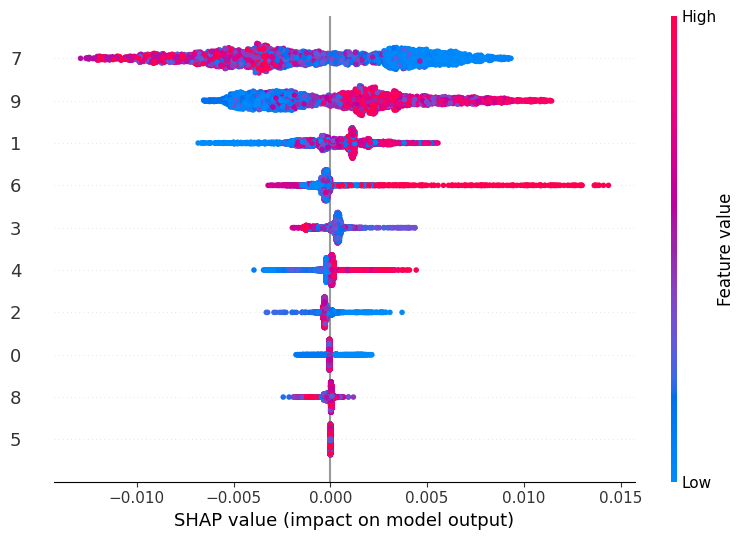

In [75]:
best_model = trained_models['RandomForest_DropNotScaled']['model']
X_test_shap = X_test_dict['DropNotScaled']

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_test_shap, 
    feature_names=data.columns.tolist(),
    show=False
)
plt.tight_layout()
plt.show()